In [4]:
import stim

from spidercat.utils import qasm_to_stim
from spiderstate.cat_at_origin import *
from spiderstate.utils import load_qecc, count_operations, get_project_root
from spiderstate.fault_tolerance_verification import verify_ftsp
from spiderstate.stim_utils import get_circuit_depth

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
code = "23_1_7"
max_col_ops = 100

print(f"Loading QECC: {code}")
is_self_dual, H_x, H_z, L_x, L_z, d = load_qecc(code)

final_circ = cat_at_origin_with_verification(
    H_x=H_x, H_z=H_z, L_x=L_x, L_z=L_z, d=d,
    max_col_ops=max_col_ops, verbose=True, first_layer="X", top_n=100, num_circuits=1,
)

print("\n--- Final Fault Tolerant Verification Circuit ---")
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")

Loading QECC: 23_1_7
Configuring stabilizers for logical |0> state preparation...
Optimizing parity matrix (max_col_ops=100, num_circuits=1)...



Finding unique matrix configuration: 100%|██████████| 1/1 [00:02<00:00,  2.26s/it]

Cost of final M: 20
Chosen CNOT gates: [(7, 4), (2, 4), (10, 5), (10, 3), (8, 3), (8, 17), (15, 8), (15, 9), (0, 8), (11, 6), (18, 19), (13, 22), (16, 18), (20, 3), (1, 20), (1, 5), (13, 19), (13, 12), (4, 3), (0, 4), (9, 22), (6, 20), (17, 18), (17, 12), (4, 17), (9, 5), (4, 9), (6, 8), (4, 6), (19, 4), (3, 19)]
Computing initial single faults...

Running verification stabilizers search for t=3 layers (top_n=100, first_layer=X)...

--- X Faults Verification (Non-FT) ---
  [Layer 1] Expanding beam of size 1:
  -> Kept top 5 states. Best Lookahead Score: 76.72
  [Layer 2] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 76.72
  [Layer 3] Expanding beam of size 5:
  -> Kept top 5 states. Best Lookahead Score: 76.72
  [Chosen Stabilizers] (Violations: 5)
    -> Layer 1: ['00010010011000101101000', '00101100001010000001010', '01010011000001000010010', '01100000110011100000001', '10000101000110100110000', '10001001100000010000111']
    -> Layer 2: ['000001101100110000

Finding unique matrix configuration: 100%|██████████| 1/1 [00:52<00:00, 52.61s/it]


--- Final Fault Tolerant Verification Circuit ---
Total Qubits: 63
Num CX: 267
Total instructions: 323
Depth: 64


Total Qubits: 63
Num CX: 267
Total instructions: 323
Depth: 64


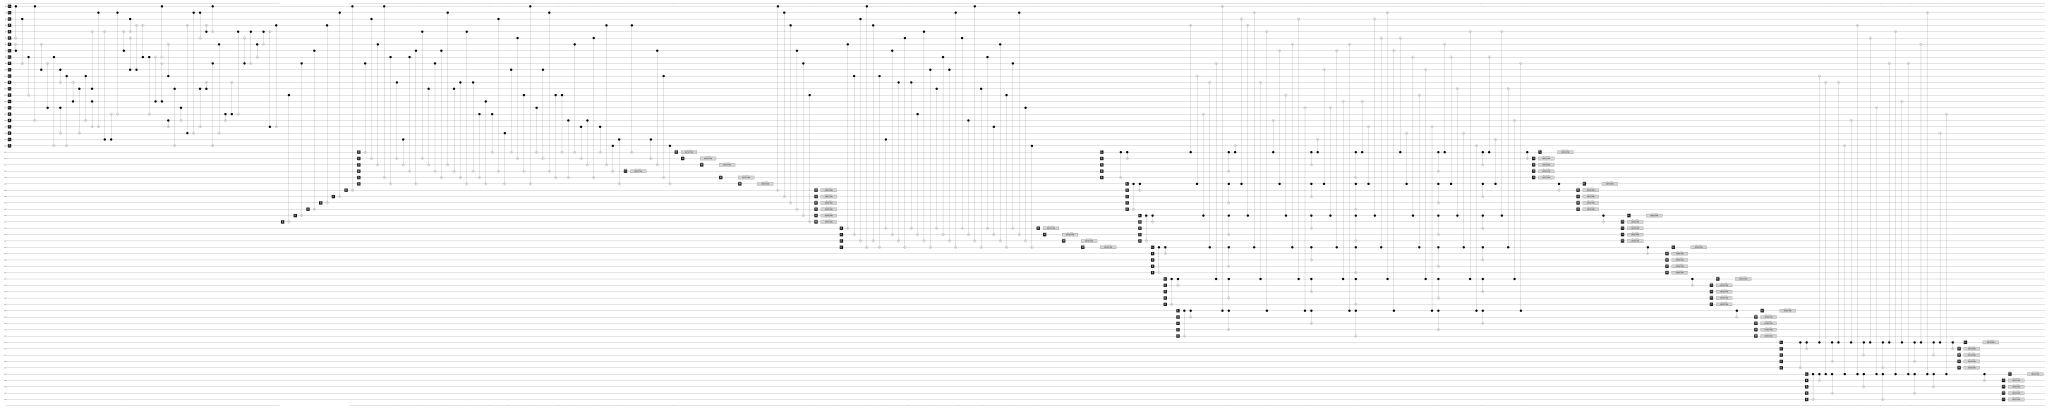

In [11]:
print(f"Total Qubits: {final_circ.num_qubits}")
print(f"Num CX: {count_operations(final_circ)[0]}")
print(f"Total instructions: {sum(count_operations(final_circ))}")
print(f"Depth: {get_circuit_depth(final_circ)}")

final_circ.diagram('timeline-svg')

In [8]:
circuit = final_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(5)
meas_samples = samples[:, -H_z.shape[1]:]
print(meas_samples @ H_z.T % 2)
print((meas_samples @ L_z.T % 2).T)

[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0]
 [0 0 0 0 0]]


In [ ]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
        prep_circ=final_circ,
        H_primary=H_z, L_primary=np.atleast_2d(L_z),
        H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
        d=d, t=d // 2,
        primary_basis="Z", conjugate_basis="X",
        verbose=True
    )
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis via Combinatorics (d=7, t=3)...


In [46]:
with open("res_exhaustive.svg", "w") as f:
    f.write(str(res_exhaustive.diagram("timeline-svg")))

AttributeError: 'bool' object has no attribute 'diagram'

In [39]:
if False:
    file = get_project_root().joinpath("good_circuits", f"{code}.stim")
    with open(file, "w") as f:
        f.write(str(final_circ))

Num CX: 194
Total instructions: 232
Depth: 31


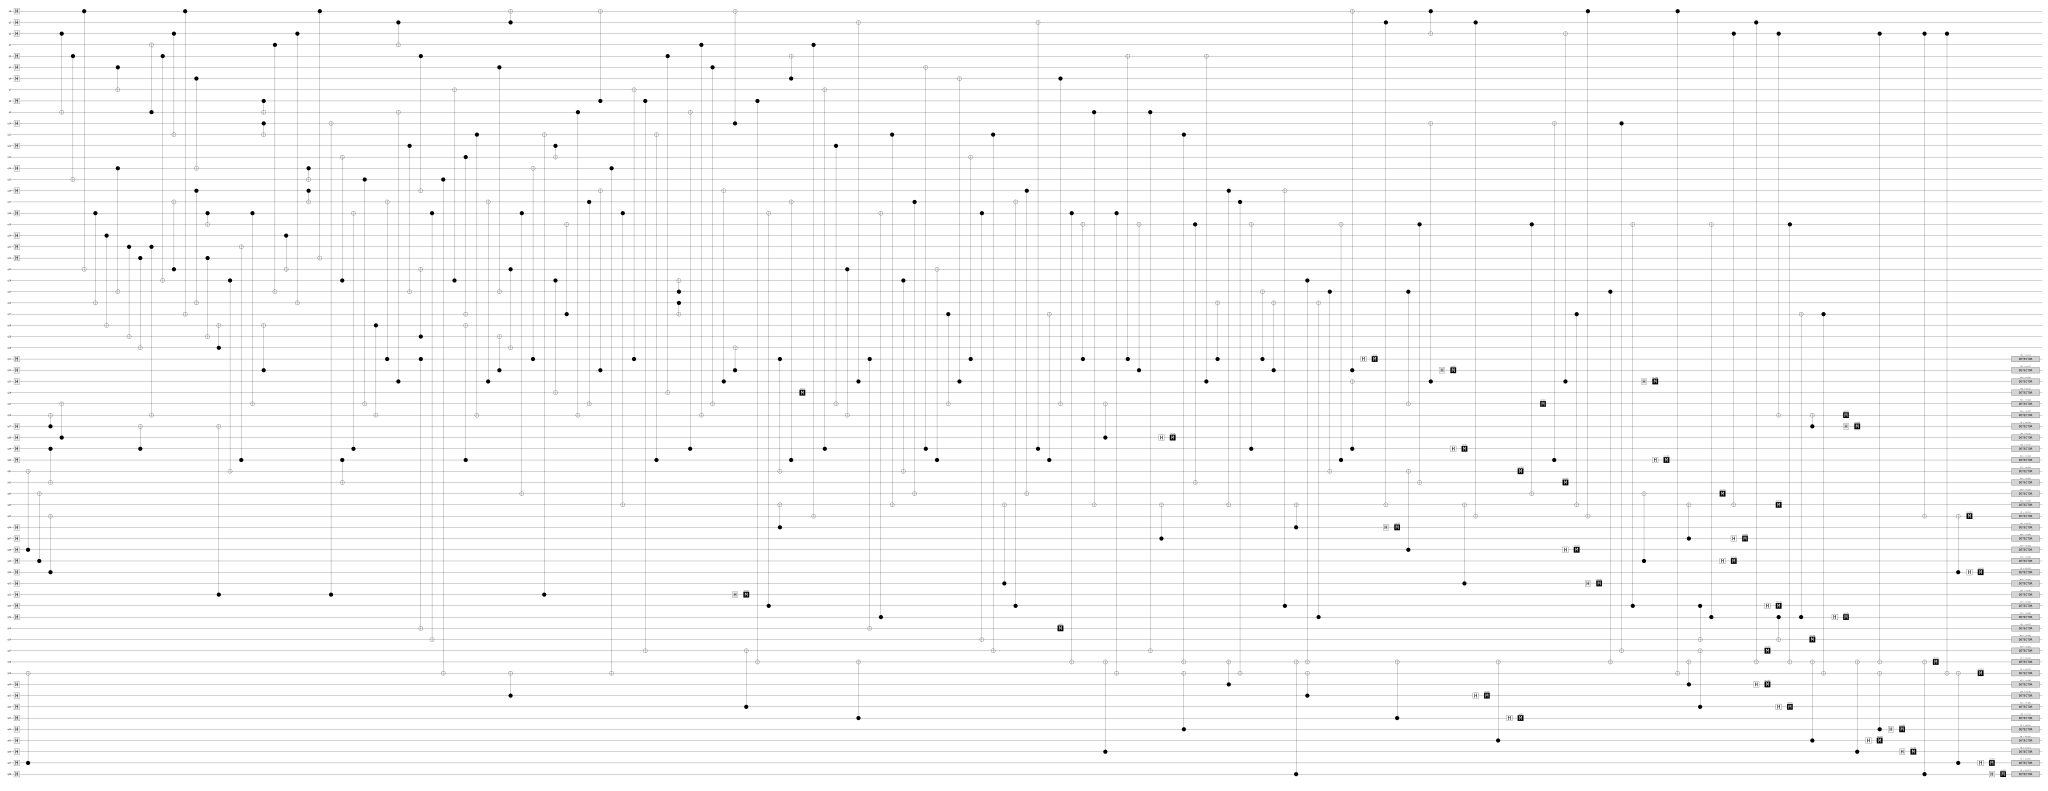

In [40]:
bens_circ = qasm_to_stim("""
OPENQASM 2.0;
include "qelib1.inc";
qreg q[69];
creg c[38];
h q[68];
h q[66];
h q[67];
h q[60];
h q[61];
h q[62];
h q[63];
h q[64];
h q[65];
h q[52];
h q[53];
h q[54];
h q[51];
h q[46];
h q[47];
h q[48];
h q[49];
h q[50];
h q[39];
h q[40];
h q[37];
h q[38];
h q[31];
h q[32];
h q[33];
h q[0];
h q[1];
h q[2];
h q[4];
h q[5];
h q[6];
h q[8];
h q[10];
h q[12];
h q[14];
h q[16];
h q[18];
h q[20];
h q[21];
h q[22];
cx q[67], q[59];
cx q[48], q[41];
cx q[49], q[43];
cx q[50], q[45];
cx q[39], q[42];
cx q[37], q[36];
cx q[38], q[35];
cx q[2], q[9];
cx q[4], q[15];
cx q[0], q[23];
cx q[18], q[26];
cx q[20], q[28];
cx q[14], q[25];
cx q[5], q[7];
cx q[21], q[29];
cx q[22], q[30];
cx q[39], q[37];
cx q[21], q[36];
cx q[9], q[3];
cx q[4], q[24];
cx q[2], q[11];
cx q[23], q[17];
cx q[0], q[27];
cx q[6], q[14];
cx q[16], q[26];
cx q[22], q[29];
cx q[18], q[19];
cx q[30], q[28];
cx q[52], q[37];
cx q[24], q[41];
cx q[40], q[21];
cx q[18], q[35];
cx q[32], q[28];
cx q[8], q[9];
cx q[10], q[11];
cx q[3], q[25];
cx q[20], q[23];
cx q[2], q[26];
cx q[16], q[17];
cx q[14], q[15];
cx q[0], q[22];
cx q[52], q[10];
cx q[24], q[13];
cx q[40], q[42];
cx q[39], q[18];
cx q[15], q[35];
cx q[28], q[36];
cx q[31], q[17];
cx q[33], q[9];
cx q[1], q[3];
cx q[12], q[25];
cx q[29], q[23];
cx q[4], q[16];
cx q[31], q[55];
cx q[18], q[56];
cx q[15], q[59];
cx q[24], q[7];
cx q[13], q[27];
cx q[40], q[28];
cx q[11], q[36];
cx q[33], q[17];
cx q[32], q[29];
cx q[5], q[25];
cx q[23], q[30];
cx q[1], q[0];
cx q[61], q[59];
cx q[18], q[43];
cx q[31], q[14];
cx q[52], q[11];
cx q[24], q[34];
cx q[12], q[13];
cx q[27], q[19];
cx q[9], q[36];
cx q[17], q[35];
cx q[32], q[16];
cx q[8], q[0];
cx q[14], q[59];
cx q[18], q[44];
cx q[31], q[7];
cx q[8], q[57];
cx q[40], q[11];
cx q[4], q[34];
cx q[26], q[27];
cx q[25], q[24];
cx q[39], q[9];
cx q[3], q[36];
cx q[5], q[35];
cx q[33], q[16];
cx q[32], q[30];
cx q[10], q[0];
h q[52];
measure q[52] -> c[0];
cx q[62], q[57];
cx q[8], q[58];
cx q[53], q[18];
cx q[46], q[44];
cx q[31], q[41];
cx q[40], q[17];
cx q[6], q[4];
measure q[34] -> c[1];
cx q[3], q[45];
cx q[39], q[7];
cx q[12], q[35];
cx q[23], q[36];
cx q[33], q[1];
cx q[63], q[58];
cx q[31], q[55];
cx q[54], q[18];
cx q[11], q[44];
cx q[24], q[41];
cx q[17], q[43];
cx q[39], q[5];
cx q[40], q[23];
cx q[27], q[35];
cx q[33], q[6];
cx q[31], q[13];
cx q[18], q[56];
cx q[11], q[57];
cx q[51], q[44];
cx q[53], q[17];
cx q[16], q[43];
cx q[39], q[1];
cx q[40], q[27];
cx q[6], q[35];
measure q[55] -> c[2];
cx q[18], q[58];
cx q[31], q[19];
cx q[9], q[44];
cx q[38], q[35];
cx q[66], q[58];
cx q[18], q[59];
cx q[31], q[4];
cx q[32], q[19];
cx q[9], q[57];
cx q[47], q[44];
h q[38];
measure q[38] -> c[3];
cx q[11], q[58];
cx q[64], q[59];
cx q[19], q[42];
cx q[33], q[4];
cx q[31], q[26];
cx q[16], q[44];
cx q[60], q[58];
cx q[17], q[59];
cx q[39], q[19];
cx q[31], q[25];
cx q[32], q[26];
cx q[53], q[16];
cx q[46], q[44];
cx q[68], q[58];
cx q[24], q[58];
cx q[61], q[59];
cx q[54], q[26];
cx q[25], q[41];
cx q[40], q[19];
cx q[39], q[33];
cx q[32], q[0];
h q[31];
measure q[31] -> c[4];
cx q[1], q[44];
h q[46];
measure q[46] -> c[5];
cx q[63], q[58];
cx q[48], q[41];
cx q[25], q[35];
cx q[19], q[42];
cx q[33], q[10];
cx q[0], q[2];
h q[32];
measure q[32] -> c[6];
h q[39];
measure q[39] -> c[7];
cx q[51], q[44];
cx q[1], q[45];
h q[61];
measure q[61] -> c[8];
cx q[65], q[58];
h q[63];
measure q[63] -> c[9];
measure q[41] -> c[10];
cx q[19], q[43];
measure q[35] -> c[11];
cx q[40], q[10];
cx q[33], q[2];
measure q[42] -> c[12];
h q[48];
measure q[48] -> c[13];
cx q[27], q[44];
cx q[0], q[45];
h q[51];
measure q[51] -> c[14];
cx q[25], q[58];
cx q[10], q[57];
cx q[53], q[19];
cx q[49], q[43];
h q[33];
measure q[33] -> c[15];
h q[40];
measure q[40] -> c[16];
cx q[0], q[59];
cx q[47], q[44];
cx q[60], q[58];
cx q[62], q[57];
cx q[53], q[56];
cx q[54], q[19];
measure q[43] -> c[17];
h q[49];
measure q[49] -> c[18];
cx q[2], q[44];
h q[47];
measure q[47] -> c[19];
cx q[1], q[58];
h q[60];
measure q[60] -> c[20];
measure q[57] -> c[21];
h q[53];
measure q[53] -> c[22];
cx q[54], q[56];
cx q[2], q[36];
measure q[44] -> c[23];
h q[62];
measure q[62] -> c[24];
cx q[19], q[58];
cx q[54], q[27];
cx q[37], q[36];
measure q[56] -> c[25];
cx q[65], q[58];
cx q[27], q[59];
h q[54];
measure q[54] -> c[26];
measure q[36] -> c[27];
h q[37];
measure q[37] -> c[28];
cx q[66], q[58];
h q[65];
measure q[65] -> c[29];
cx q[64], q[59];
cx q[2], q[58];
h q[64];
measure q[64] -> c[30];
h q[66];
measure q[66] -> c[31];
cx q[68], q[58];
cx q[2], q[45];
measure q[58] -> c[32];
cx q[2], q[59];
cx q[50], q[45];
cx q[67], q[59];
measure q[45] -> c[33];
h q[50];
measure q[50] -> c[34];
measure q[59] -> c[35];
h q[67];
measure q[67] -> c[36];
h q[68];
measure q[68] -> c[37];
""")
for i in range(bens_circ.num_measurements):
    bens_circ.append("DETECTOR", [stim.target_rec(-i-1)])


print(f"Num CX: {count_operations(bens_circ)[0]}")
print(f"Total instructions: {sum(count_operations(bens_circ))}")
print(f"Depth: {get_circuit_depth(bens_circ)}")
bens_circ.diagram("timeline-svg")

In [8]:
circuit = bens_circ.copy()
circuit.append("M", range(H_z.shape[1]))
samples = circuit.compile_sampler().sample(10)
flags = samples[:, :-H_z.shape[1]]
meas_samples = samples[:, -H_z.shape[1]:]
print(flags.astype(int))
print(meas_samples @ H_z.T % 2)
print(meas_samples @ L_z.T % 2)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [11]:
print("\nRunning Fast DEM/SAT FT Verification...")
res_exhaustive = verify_ftsp(
    prep_circ=bens_circ,
    H_primary=H_z, L_primary=np.atleast_2d(L_z),
    H_conjugate=H_x, L_conjugate=np.atleast_2d(L_x),
    d=d, t=d // 2,
    primary_basis="Z", conjugate_basis="X",
    verbose=True
)
print("Verification Result:", res_exhaustive is True)


Running Fast DEM/SAT FT Verification...

  [Primary] Evaluating Z-basis (d=4, t=2)...
RX 2
Z_ERROR(0.000666667) 2
R 3
X_ERROR(0.000666667) 3
RX 4
Z_ERROR(0.000666667) 4
R 5
X_ERROR(0.000666667) 5
RX 8
Z_ERROR(0.000666667) 8
R 9
X_ERROR(0.000666667) 9
R 16
X_ERROR(0.000666667) 16
R 17
X_ERROR(0.000666667) 17
R 32
X_ERROR(0.000666667) 32
RX 33
Z_ERROR(0.000666667) 33
CX 2 3
DEPOLARIZE1(0.001) 2 3
CX 4 5
DEPOLARIZE1(0.001) 4 5
CX 8 9
DEPOLARIZE1(0.001) 8 9
CX 16 17
DEPOLARIZE1(0.001) 16 17
CX 33 32
DEPOLARIZE1(0.001) 33 32
RX 0
Z_ERROR(0.000666667) 0
RX 1
Z_ERROR(0.000666667) 1
R 6
X_ERROR(0.000666667) 6
R 7
X_ERROR(0.000666667) 7
R 10
X_ERROR(0.000666667) 10
R 11
X_ERROR(0.000666667) 11
R 18
X_ERROR(0.000666667) 18
R 19
X_ERROR(0.000666667) 19
CX 0 2
DEPOLARIZE1(0.001) 0 2
CX 1 3
DEPOLARIZE1(0.001) 1 3
CX 4 6
DEPOLARIZE1(0.001) 4 6
CX 5 7
DEPOLARIZE1(0.001) 5 7
CX 8 10
DEPOLARIZE1(0.001) 8 10
CX 9 11
DEPOLARIZE1(0.001) 9 11
CX 16 18
DEPOLARIZE1(0.001) 16 18
CX 17 19
DEPOLARIZE1(0.001) 1

ValueError: The circuit contains non-deterministic detectors.

To make an SVG picture of the problem, you can use the python API like this:
    your_circuit.diagram('detslice-with-ops-svg', tick=range(0, 5), filter_coords=['D11', ])
or the command line API like this:
    stim diagram --in your_circuit_file.stim --type detslice-with-ops-svg --tick 0:5 --filter_coords D11 > output_image.svg

This was discovered while analyzing a Z-basis reset (R) on:
    qubit 16

The collapse anti-commuted with these detectors/observables:
    D11

The backward-propagating error sensitivity for D11 was:
    X2
    X4
    X8
    X16

Circuit stack trace:
    at instruction #13 [which is R 16]

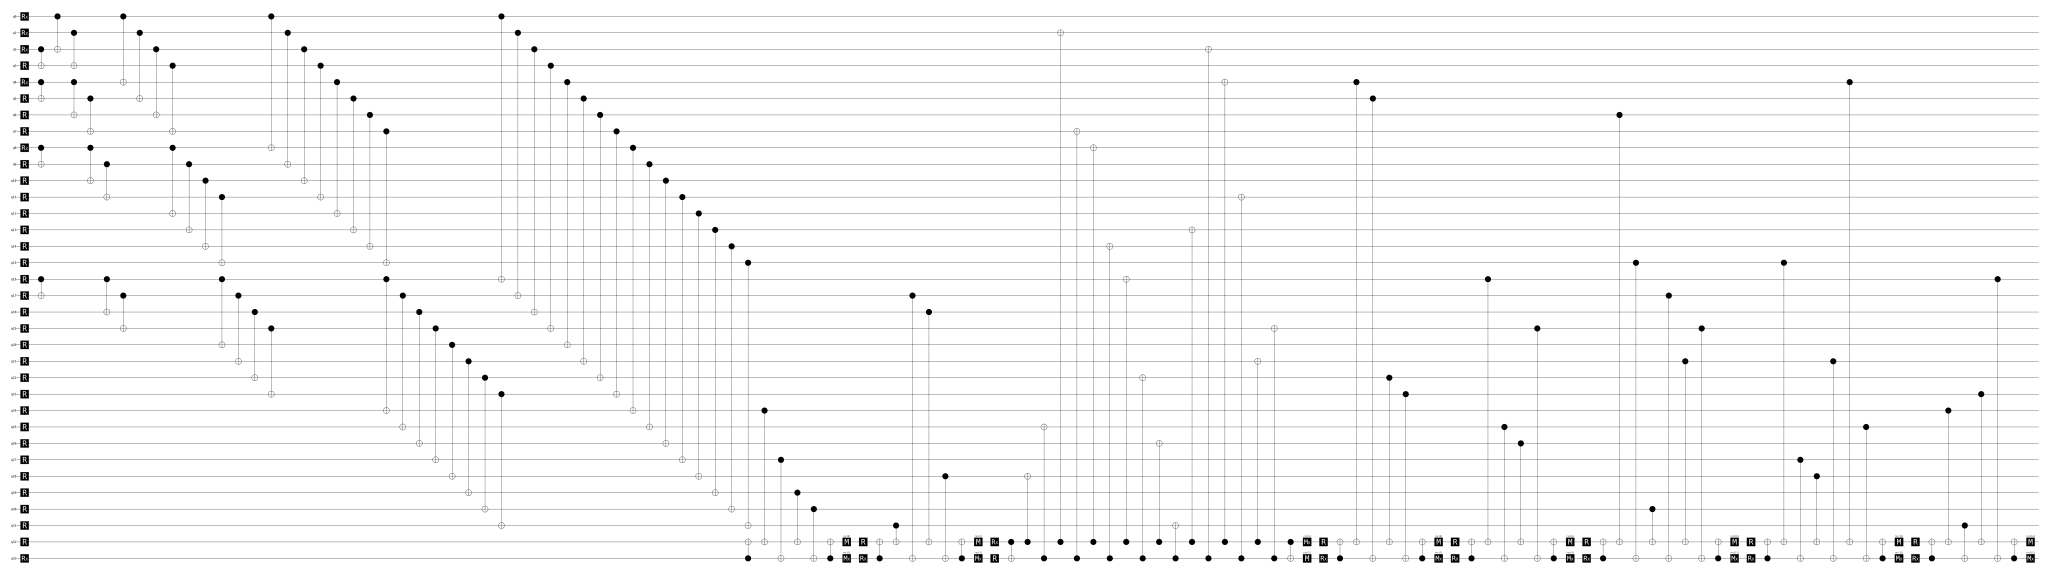

In [170]:
bens_circ = stim.Circuit("""
RX 0 1 2
R 3
RX 4
R 5 6 7
RX 8
R 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32
RX 33
CX 2 3 4 5 8 9 16 17 0 2 1 3 4 6 5 7 8 10 9 11 16 18 17 19 0 4 1 5 2 6 3 7 8 12 9 13 10 14 11 15 16 20 17 21 18 22 19 23 0 8 1 9 2 10 3 11 4 12 5 13 6 14 7 15 16 24 17 25 18 26 19 27 20 28 21 29 22 30 23 31 0 16 1 17 2 18 3 19 4 20 5 21 6 22 7 23 8 24 9 25 10 26 11 27 12 28 13 29 14 30 15 31 33 32 24 32 27 33 29 32 30 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 31 32 17 33 18 32 28 33 33 32
M 32
MX 33
RX 32
R 33
CX 32 33 32 28 33 25 32 1 33 7 32 8 33 14 32 16 33 22 32 26 33 31 32 13 33 2 32 4 33 11 32 21 33 19 32 33
MX 32
M 33
R 32
RX 33
CX 33 32 4 32 5 33 22 32 23 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 16 32 25 33 26 32 19 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 6 32 15 33 30 32 17 33 21 32 19 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 15 32 27 33 28 32 21 33 4 32 25 33 33 32
M 32
MX 33
R 32
RX 33
CX 33 32 24 32 31 33 23 32 16 33 33 32
M 32
MX 33
""").diagram('timeline-svg')

In [15]:
print(res_exhaustive)

RX 0
R 6
RX 7
R 8 10
RX 11
R 12
RX 22
CX 0 6 7 8 11 12 22 10
R 1
RX 2 13
R 20
CX 0 1 2 12 22 20 13 10
R 3
RX 5 14
R 18
CX 14 1 2 18 5 20 13 3
R 9 15
RX 16 17
CX 14 15 16 18 5 9
X 5
CX 17 3
RX 19
R 21
CX 16 15 19 9 17 21 19 21
TICK
CX 22 6 16 8 11 3 14 21 2 10 12 1 5 18
R 4
CX 22 4 7 3 14 20 11 15 19 12 21 18 16 4 11 6 3 1 10 15 9 4 5 3 21 6 0 9 11 4 3 21 0 8 10 9 8 20 3 10 8 12 3 8 4 3 1 4
TICK
TICK
R 27
CX 12 27
TICK
TICK
TICK
R 35
CX 4 35
TICK
R 26
CX 10 26
R 23 24 25
CX 4 23 6 24 5 25
TICK
TICK
R 34
CX 3 34
TICK
TICK
R 42
CX 21 42
TICK
CX 21 23 3 24 12 25
TICK
CX 7 23 12 24
TICK
TICK
R 38
CX 11 38
TICK
CX 13 23 8 24
X 8
CX 11 25
TICK
TICK
R 36
CX 5 36
TICK
TICK
R 40
CX 13 40
TICK
CX 17 23 5 24 13 25
TICK
TICK
R 41
CX 20 41
TICK
CX 8 23 20 24 18 25
TICK
TICK
R 33
CX 1 33
TICK
CX 10 24 1 25
TICK
CX 10 23 19 24 2 25
TICK
TICK
R 37
CX 10 37
TICK
TICK
R 39
CX 12 39
TICK
M 23
DETECTOR rec[-1]
M 24
DETECTOR rec[-1]
M 25
DETECTOR rec[-1]
CX 10 26 12 27
TICK
M 26 27
DETECTOR rec[-1]
DETECTOR

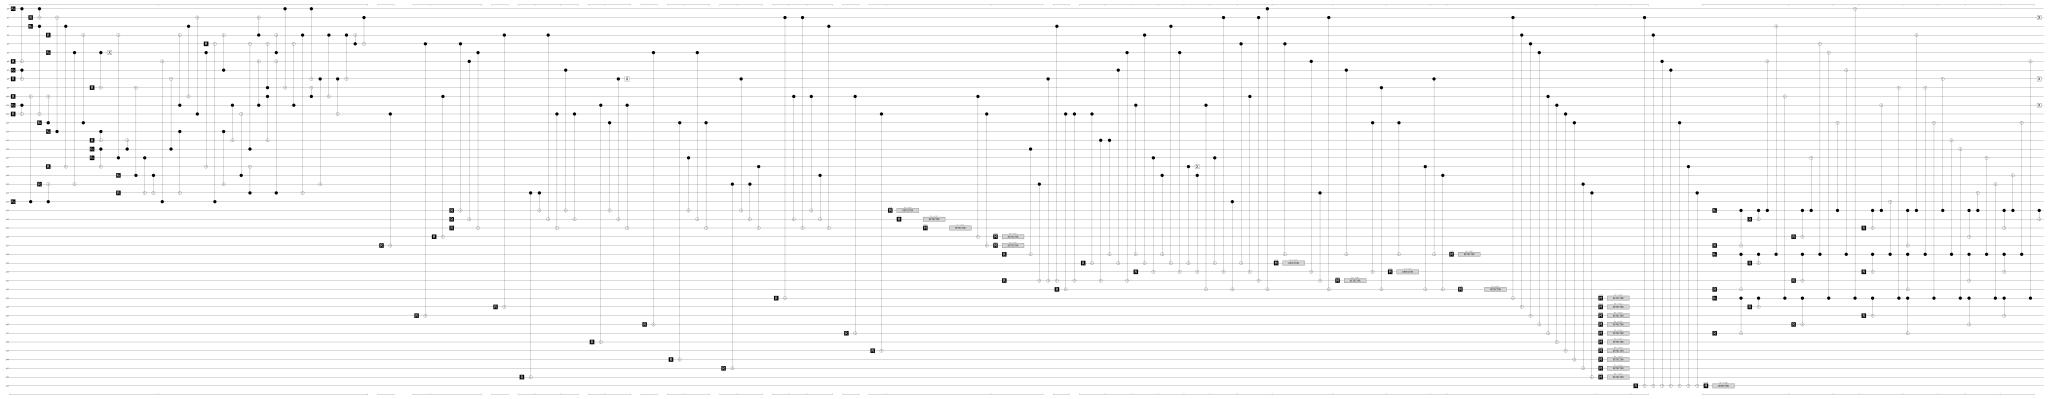

In [20]:
stim.Circuit("""RX 0
R 6
RX 7
R 8 10
RX 11
R 12
RX 22
CX 0 6 7 8 11 12 22 10
R 1
RX 2 13
R 20
CX 0 1 2 12 22 20 13 10
R 3
RX 5 14
R 18
CX 14 1 2 18 5 20 13 3
R 9 15
RX 16 17
CX 14 15 16 18 5 9
X 5
CX 17 3
RX 19
R 21
CX 16 15 19 9 17 21 19 21
TICK
CX 22 6 16 8 11 3 14 21 2 10 12 1 5 18
R 4
CX 22 4 7 3 14 20 11 15 19 12 21 18 16 4 11 6 3 1 10 15 9 4 5 3 21 6 0 9 11 4 3 21 0 8 10 9 8 20 3 10 8 12 3 8 4 3 1 4
TICK
TICK
R 27
CX 12 27
TICK
TICK
TICK
R 35
CX 4 35
TICK
R 26
CX 10 26
R 23 24 25
CX 4 23 6 24 5 25
TICK
TICK
R 34
CX 3 34
TICK
TICK
R 42
CX 21 42
TICK
CX 21 23 3 24 12 25
TICK
CX 7 23 12 24
TICK
TICK
R 38
CX 11 38
TICK
CX 13 23 8 24
X 8
CX 11 25
TICK
TICK
R 36
CX 5 36
TICK
TICK
R 40
CX 13 40
TICK
CX 17 23 5 24 13 25
TICK
TICK
R 41
CX 20 41
TICK
CX 8 23 20 24 18 25
TICK
TICK
R 33
CX 1 33
TICK
CX 10 24 1 25
TICK
CX 10 23 19 24 2 25
TICK
TICK
R 37
CX 10 37
TICK
TICK
R 39
CX 12 39
TICK
M 23
DETECTOR rec[-1]
M 24
DETECTOR rec[-1]
M 25
DETECTOR rec[-1]
CX 10 26 12 27
TICK
M 26 27
DETECTOR rec[-1]
DETECTOR rec[-2]
R 28 31
CX 16 28 20 31
TICK
CX 8 31
TICK
R 32
CX 2 31 12 32
TICK
CX 12 31
TICK
R 29
CX 12 29 15 31
TICK
CX 15 28 7 29 5 31
TICK
R 30
CX 11 28 3 29 17 30
TICK
CX 19 28 2 29 5 30
TICK
CX 18 29
X 18
CX 19 30 11 32
TICK
CX 17 29 1 30 22 32
TICK
CX 4 29 10 30 1 31 0 32
TICK
M 29
DETECTOR rec[-1]
CX 4 28 6 30 21 31 1 32
TICK
M 31
DETECTOR rec[-1]
CX 7 28 13 30 9 32
TICK
M 30
DETECTOR rec[-1]
CX 13 28 18 32
TICK
CX 8 28 19 32
TICK
M 28
DETECTOR rec[-1]
M 32
DETECTOR rec[-1]
CX 1 33 3 34 4 35 5 36 10 37 11 38 12 39 13 40 20 41 21 42
TICK
M 33 34 35 36 37 38 39 40 41 42
DETECTOR rec[-1]
DETECTOR rec[-2]
DETECTOR rec[-3]
DETECTOR rec[-4]
DETECTOR rec[-5]
DETECTOR rec[-6]
DETECTOR rec[-7]
DETECTOR rec[-8]
DETECTOR rec[-9]
DETECTOR rec[-10]
TICK
R 43
CX 1 43
TICK
CX 3 43
TICK
CX 6 43
TICK
CX 7 43
TICK
CX 13 43
TICK
CX 18 43
TICK
CX 21 43
TICK
M 43
DETECTOR rec[-1]
R 27
RX 23
R 32
RX 28
R 37
RX 33
CX 23 27 28 32 33 37
R 24 29 34
CX 23 24 28 29 33 34 23 6 28 2 33 10
TICK
R 26 31 36
CX 23 26 28 31 33 36 23 17 28 4 33 5
TICK
CX 23 13 28 7 33 0
TICK
R 25 30 35
CX 23 25 28 30 33 35 23 11 28 22 33 9
TICK
CX 23 27 28 32 33 37 23 3 28 9 33 13
TICK
CX 23 8 28 15 33 16
TICK
CX 23 26 28 31 33 36 23 21 28 17 33 20
TICK
CX 23 25 28 30 33 35 23 19 28 13 33 6
TICK
CX 23 24
# M 25 26 27 24
# DETECTOR rec[-1]
# DETECTOR rec[-2]
# DETECTOR rec[-3]
# DETECTOR rec[-4]
# MX 23
# DETECTOR rec[-1]
# CX 28 29
# M 30 31 32 29
# DETECTOR rec[-1]
# DETECTOR rec[-2]
# DETECTOR rec[-3]
# DETECTOR rec[-4]
# MX 28
# DETECTOR rec[-1]
# CX 33 34
# M 35 36 37 34
# DETECTOR rec[-1]
# DETECTOR rec[-2]
# DETECTOR rec[-3]
# DETECTOR rec[-4]
# MX 33
# DETECTOR rec[-1]
# R 42
# RX 38
# R 47
# RX 43
# R 52
# RX 48
# R 57
# RX 53
# CX 38 42 43 47 48 52 53 57
# R 39 44 49 54
# CX 38 39 43 44 48 49 53 54 38 2 43 3 48 6 53 10
# TICK
# R 41 46 51 56
# CX 38 41 43 46 48 51 53 56 38 4 43 6 48 0 53 14
# TICK
# CX 38 5 43 13 48 17 53 1
# TICK
# R 40 45 50 55
# CX 38 40 43 45 48 50 53 55 38 7 43 4 48 11 53 13
# TICK
# CX 38 42 43 47 48 52 53 57 38 10 43 1 48 16 53 22
# TICK
# CX 38 15 43 16 48 12 53 5
# TICK
# CX 38 41 43 46 48 51 53 56 38 3 43 19 48 21 53 11
# TICK
# CX 38 40 43 45 48 50 53 55 38 8 43 20 48 9 53 0
# TICK
# CX 38 39
# M 40 41 42 39
# DETECTOR rec[-1]
# DETECTOR rec[-2]
# DETECTOR rec[-3]
# DETECTOR rec[-4]
# MX 38
# DETECTOR rec[-1]
# CX 43 44
# M 45 46 47 44
# DETECTOR rec[-1]
# DETECTOR rec[-2]
# DETECTOR rec[-3]
# DETECTOR rec[-4]
# MX 43
# DETECTOR rec[-1]
# CX 48 49
# M 50 51 52 49
# DETECTOR rec[-1]
# DETECTOR rec[-2]
# DETECTOR rec[-3]
# DETECTOR rec[-4]
# MX 48
# DETECTOR rec[-1]
# CX 53 54
# M 55 56 57 54
# DETECTOR rec[-1]
# DETECTOR rec[-2]
# DETECTOR rec[-3]
# DETECTOR rec[-4]
# MX 53
# DETECTOR rec[-1]
# R 62
# RX 58
# CX 58 62
# R 59
# CX 58 59 58 2
# TICK
# R 61
# CX 58 61 58 4
# TICK
# CX 58 8
# TICK
# R 60
# CX 58 60 58 9
# TICK
# CX 58 62 58 11
# TICK
# CX 58 14
# TICK
# CX 58 61 58 15
# TICK
# CX 58 60 58 20
# TICK
# CX 58 59
# M 60 61 62 59
# DETECTOR rec[-1]
# DETECTOR rec[-2]
# DETECTOR rec[-3]
# DETECTOR rec[-4]
# MX 58
# DETECTOR rec[-1]

X 1 8 11
""").diagram('timeline-svg')